In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from hmmlearn.hmm import GaussianHMM

tickers = ["SPY", "TLT", "GLD", "BTC-USD"]
start_date, end_date = "2018-01-01", "2024-01-01"

raw = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True, progress=False)
prices = raw["Close"].dropna(how="any")  # inner-join alignment across all 4 assets

log_returns = np.log(prices / prices.shift(1)).dropna(how="any")

def build_features(returns_series, horizon=21, min_periods=63):
    """Momentum + volatility, expanding-z-scored (no lookahead)."""
    mom = returns_series.rolling(horizon).sum()
    vol = returns_series.rolling(horizon).std()
    mom_z = (mom - mom.expanding(min_periods=min_periods).mean()) / mom.expanding(min_periods=min_periods).std()
    vol_z = (vol - vol.expanding(min_periods=min_periods).mean()) / vol.expanding(min_periods=min_periods).std()
    feats = pd.concat([mom_z, vol_z], axis=1)
    feats.columns = ["mom_z", "vol_z"]
    return feats.dropna()

features = {t: build_features(log_returns[t]) for t in tickers}

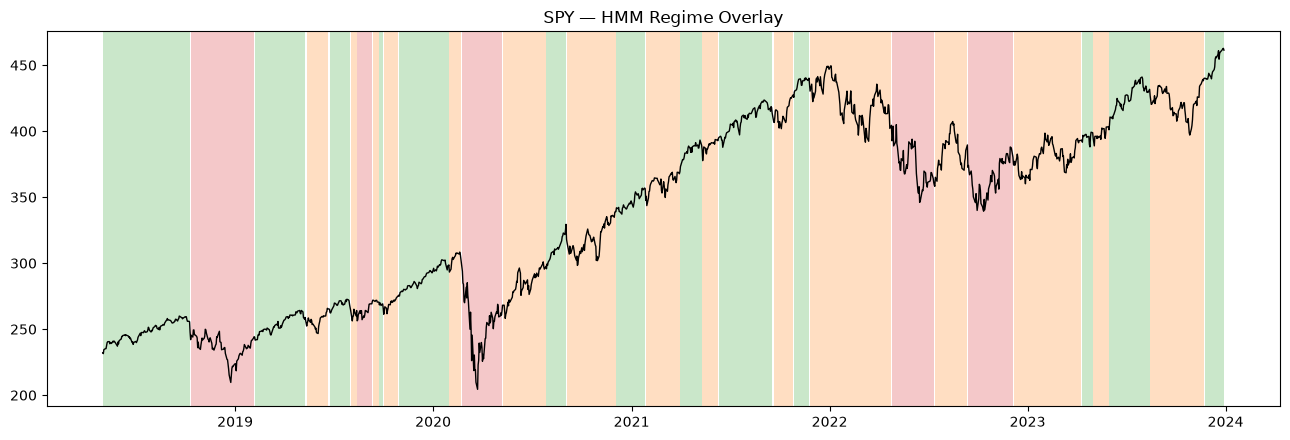

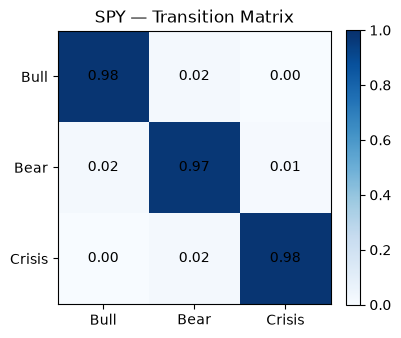

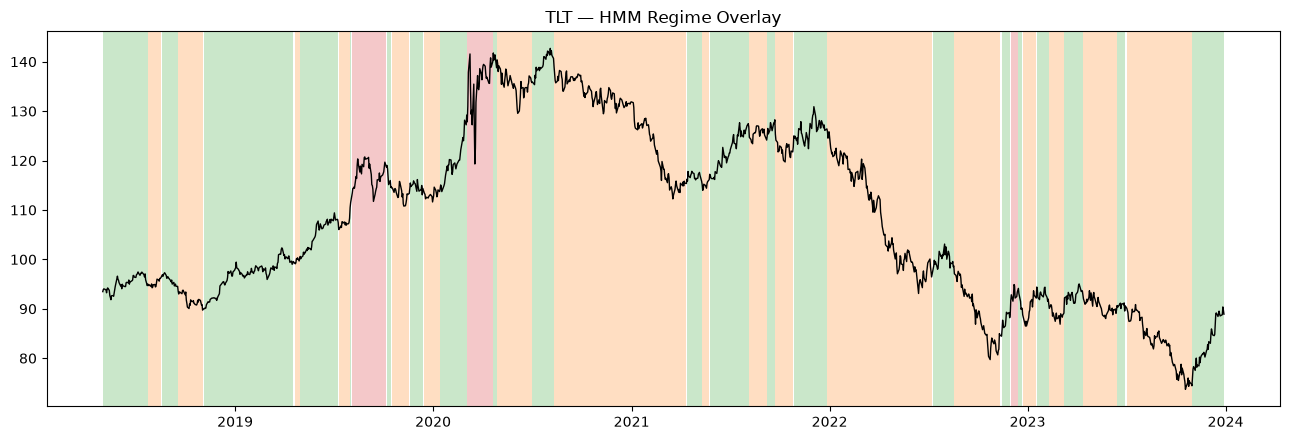

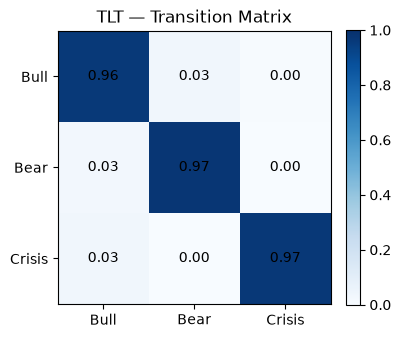

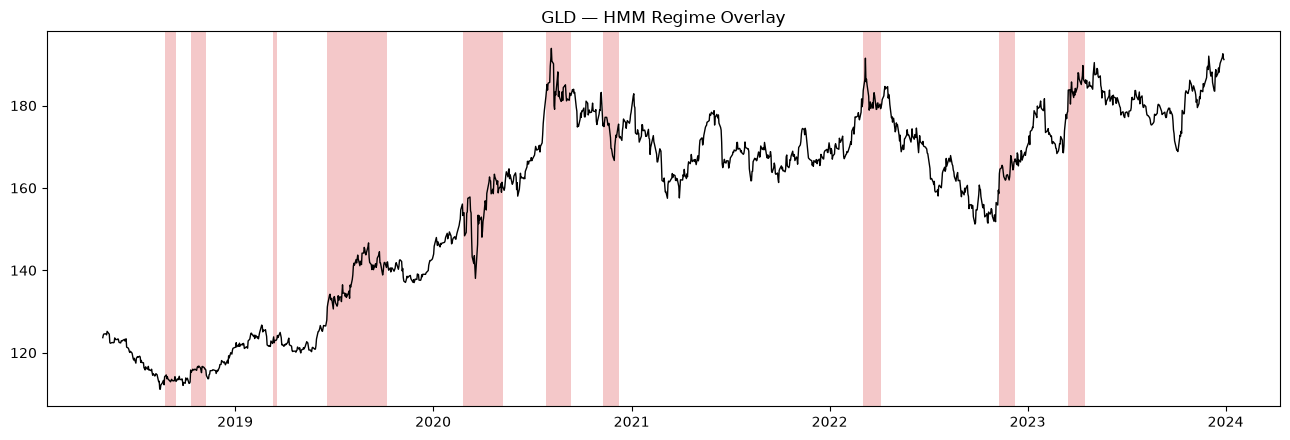

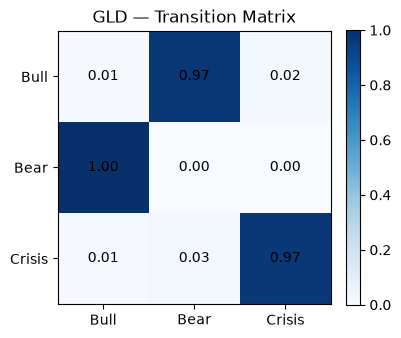

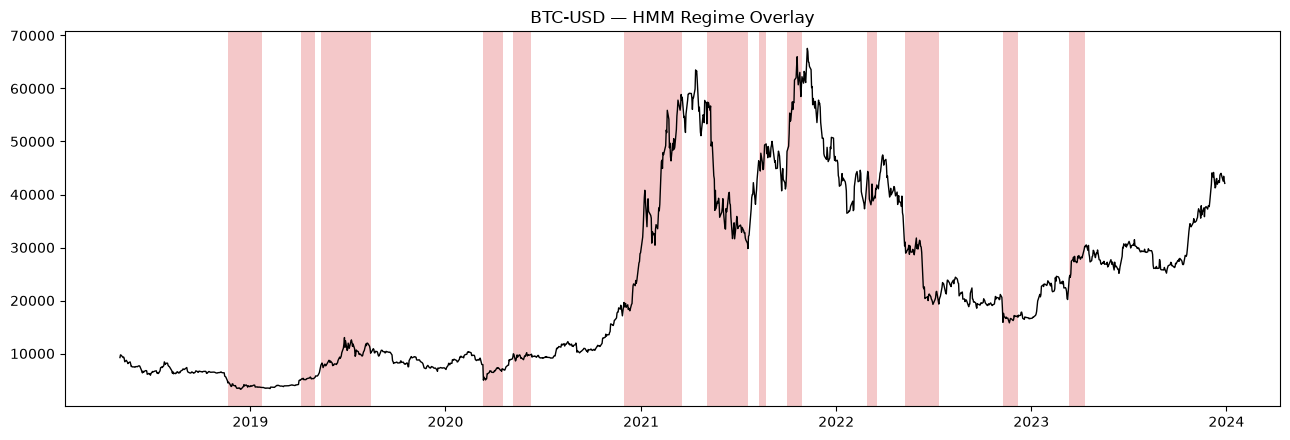

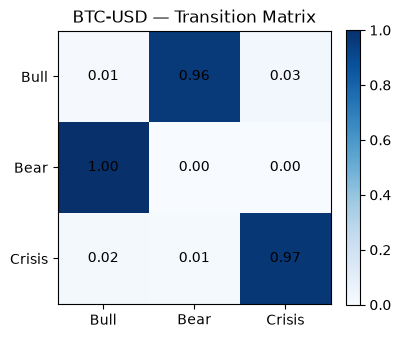

In [2]:
def label_states(means_):
    """Map arbitrary HMM state indices to Bull/Bear/Crisis using the fitted means."""
    vol_col, mom_col = means_[:, 1], means_[:, 0]
    crisis_state = int(np.argmax(vol_col))
    remaining = [s for s in range(len(means_)) if s != crisis_state]
    bull_state = remaining[0] if mom_col[remaining[0]] >= mom_col[remaining[1]] else remaining[1]
    bear_state = remaining[1] if bull_state == remaining[0] else remaining[0]
    return {bull_state: "Bull", bear_state: "Bear", crisis_state: "Crisis"}

def fit_full_hmm(X, n_states=3, seed=42):
    model = GaussianHMM(n_components=n_states, covariance_type="diag", n_iter=1000, random_state=seed)
    model.fit(X)
    return model

regime_colors = {"Bull": "tab:green", "Bear": "tab:orange", "Crisis": "tab:red"}
full_models = {}

for t in tickers:
    X = features[t].values
    model = fit_full_hmm(X)
    mapping = label_states(model.means_)
    states = np.array([mapping[s] for s in model.predict(X)])
    full_models[t] = {"model": model, "mapping": mapping, "states": states}

    df_plot = pd.DataFrame({"price": prices.loc[features[t].index, t], "regime": states}, index=features[t].index)
    df_plot["block"] = (df_plot["regime"] != df_plot["regime"].shift()).cumsum()

    fig, ax = plt.subplots(figsize=(13, 4.5))
    for _, blk in df_plot.groupby("block"):
        ax.axvspan(blk.index[0], blk.index[-1], color=regime_colors[blk["regime"].iloc[0]], alpha=0.25, lw=0)
    ax.plot(df_plot.index, df_plot["price"], color="black", lw=1)
    ax.set_title(f"{t} — HMM Regime Overlay")
    fig.tight_layout()
    plt.show()

    # Transition matrix, reordered into Bull/Bear/Crisis for readability
    order = [k for k, v in sorted(mapping.items(), key=lambda kv: ["Bull", "Bear", "Crisis"].index(kv[1]))]
    transmat_ordered = model.transmat_[np.ix_(order, order)]
    labels = [mapping[o] for o in order]

    fig, ax = plt.subplots(figsize=(4, 3.5))
    im = ax.imshow(transmat_ordered, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(3)); ax.set_xticklabels(labels)
    ax.set_yticks(range(3)); ax.set_yticklabels(labels)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{transmat_ordered[i, j]:.2f}", ha="center", va="center")
    ax.set_title(f"{t} — Transition Matrix")
    fig.colorbar(im, fraction=0.046)
    fig.tight_layout()
    plt.show()

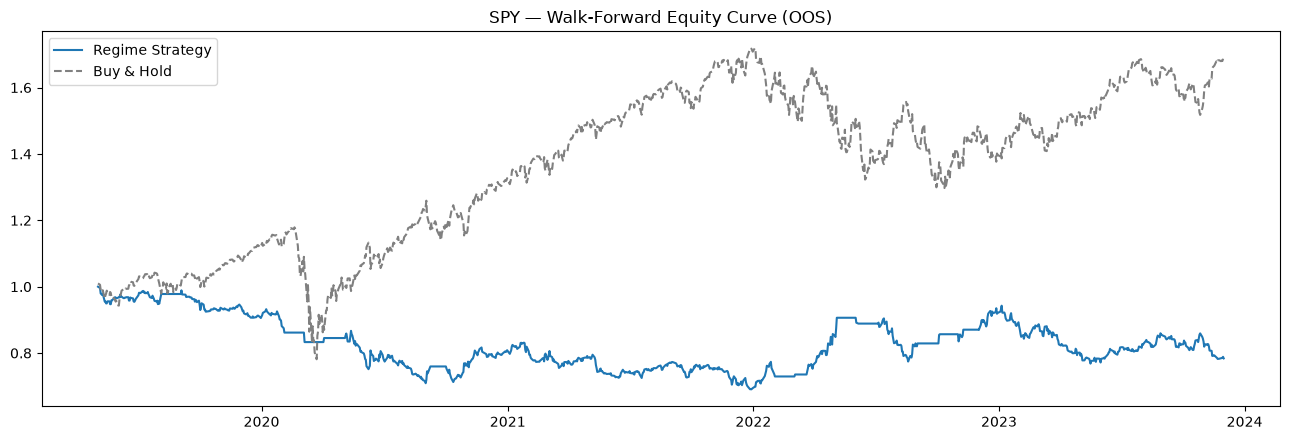

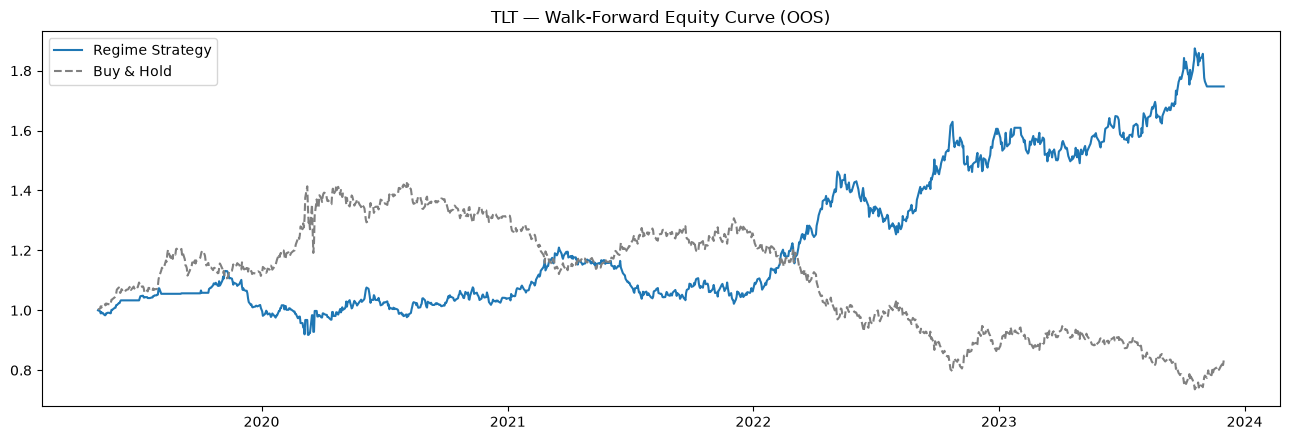

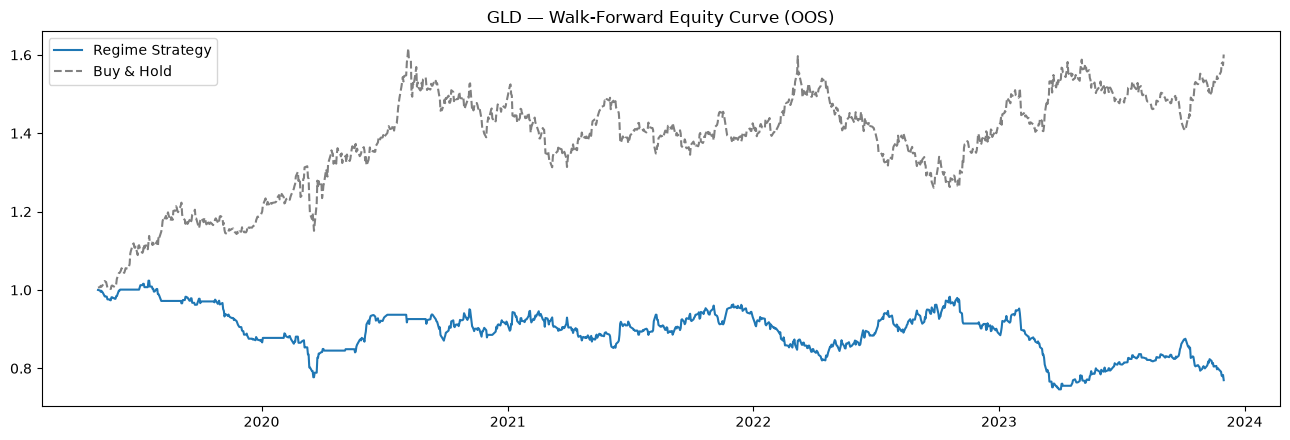

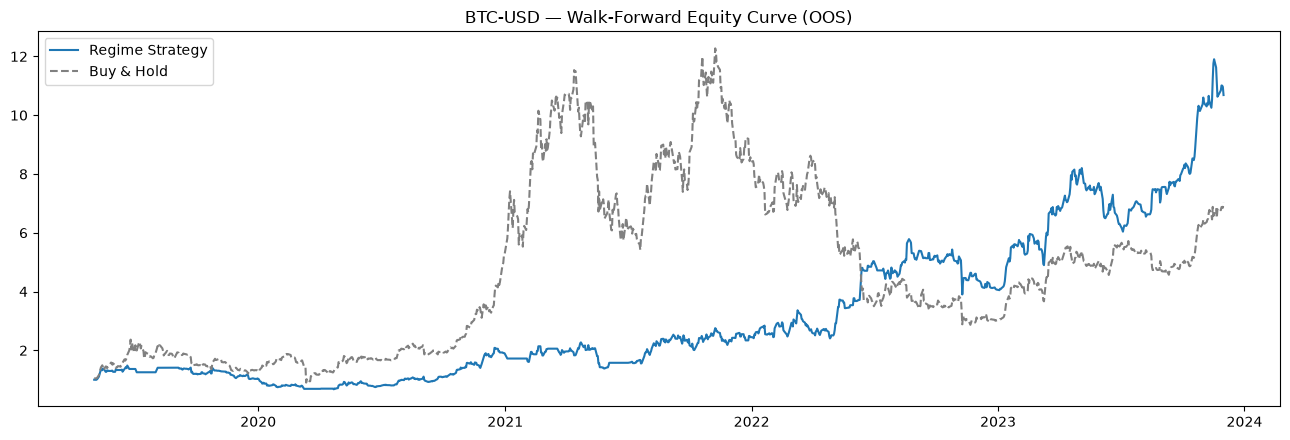

In [3]:
def expanding_walk_forward_splits(n, min_train_size=252, test_size=21, step=21):
    start_test = min_train_size
    while start_test + test_size <= n:
        yield np.arange(0, start_test), np.arange(start_test, start_test + test_size)
        start_test += step

def walk_forward_backtest(ticker, feats, rets, n_states=3, min_train_size=252, test_size=21):
    idx = feats.index
    X_full = feats.values
    r = rets.loc[idx]

    positions = pd.Series(index=idx, dtype=float)
    oos_states = pd.Series(index=idx, dtype=object)

    for train_idx, test_idx in expanding_walk_forward_splits(len(idx), min_train_size, test_size):
        X_train = X_full[train_idx]
        X_test = X_full[test_idx]

        model = GaussianHMM(n_components=n_states, covariance_type="diag", n_iter=500, random_state=42)
        model.fit(X_train)  # fit on TRAIN ONLY
        mapping = label_states(model.means_)

        test_states = [mapping[s] for s in model.predict(X_test)]
        oos_states.iloc[test_idx] = test_states

        pos_map = {"Bull": 1.0, "Bear": -1.0, "Crisis": 0.0}
        positions.iloc[test_idx] = [pos_map[s] for s in test_states]

    positions = positions.dropna()
    r = r.loc[positions.index]

    # Position decided at close of day t applies to day t+1's return (no lookahead)
    strat_returns = positions.shift(1).fillna(0) * r
    bench_returns = r  # buy-and-hold

    return positions, oos_states.dropna(), strat_returns.dropna(), bench_returns.loc[strat_returns.dropna().index]

backtest_results = {}
for t in tickers:
    positions, oos_states, strat_ret, bench_ret = walk_forward_backtest(t, features[t], log_returns[t])
    backtest_results[t] = dict(positions=positions, states=oos_states, strat_ret=strat_ret, bench_ret=bench_ret)

    strat_equity = np.exp(strat_ret.cumsum())
    bench_equity = np.exp(bench_ret.cumsum())

    fig, ax = plt.subplots(figsize=(13, 4.5))
    ax.plot(strat_equity.index, strat_equity, label="Regime Strategy", color="tab:blue")
    ax.plot(bench_equity.index, bench_equity, label="Buy & Hold", color="gray", linestyle="--")
    ax.set_title(f"{t} — Walk-Forward Equity Curve (OOS)")
    ax.legend()
    fig.tight_layout()
    plt.show()

In [4]:
def performance_metrics(returns, positions=None):
    ann_return = returns.mean() * 252
    ann_vol = returns.std() * np.sqrt(252)
    sharpe = ann_return / ann_vol if ann_vol > 0 else np.nan

    downside = returns[returns < 0]
    downside_vol = downside.std() * np.sqrt(252) if len(downside) > 0 else np.nan
    sortino = ann_return / downside_vol if downside_vol and downside_vol > 0 else np.nan

    equity = np.exp(returns.cumsum())
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    max_dd = drawdown.min()

    calmar = ann_return / abs(max_dd) if max_dd != 0 else np.nan

    turnover = positions.diff().abs().sum() if positions is not None else np.nan

    return {
        "Ann. Return": ann_return, "Ann. Vol": ann_vol, "Sharpe": sharpe,
        "Sortino": sortino, "Max Drawdown": max_dd, "Calmar": calmar, "Turnover": turnover,
    }

summary_rows = []
for t in tickers:
    res = backtest_results[t]
    strat_metrics = performance_metrics(res["strat_ret"], res["positions"].loc[res["strat_ret"].index])
    bench_metrics = performance_metrics(res["bench_ret"])

    summary_rows.append({"Ticker": t, "Strategy": "Regime (L/S)", **strat_metrics})
    summary_rows.append({"Ticker": t, "Strategy": "Buy & Hold", **{**bench_metrics, "Turnover": np.nan}})

summary_df = pd.DataFrame(summary_rows).set_index(["Ticker", "Strategy"])
summary_df = summary_df.round(4)
print(summary_df)

                      Ann. Return  Ann. Vol  Sharpe  Sortino  Max Drawdown  \
Ticker  Strategy                                                             
SPY     Regime (L/S)      -0.0531    0.1380 -0.3849  -0.5585       -0.3093   
        Buy & Hold         0.1153    0.2172  0.5310   0.6345       -0.3372   
TLT     Regime (L/S)       0.1218    0.1671  0.7287   1.0665       -0.1885   
        Buy & Hold        -0.0400    0.1808 -0.2213  -0.3410       -0.4835   
GLD     Regime (L/S)      -0.0571    0.1275 -0.4478  -0.5812       -0.2709   
        Buy & Hold         0.1027    0.1527  0.6723   0.9249       -0.2200   
BTC-USD Regime (L/S)       0.5168    0.5503  0.9393   1.2910       -0.5463   
        Buy & Hold         0.4254    0.6971  0.6103   0.7497       -0.7663   

                      Calmar  Turnover  
Ticker  Strategy                        
SPY     Regime (L/S) -0.1717     838.0  
        Buy & Hold    0.3420       NaN  
TLT     Regime (L/S)  0.6461     669.0  
        Buy & 